# Sod shock tube: backprop through the trajectory

The per-kernel gradcheck sweep (`.claude/skills/gradcheck/SKILL.md`, 15
scripts) verifies each custom warp kernel's adjoint against finite
differences *in isolation*. This notebook is the first thing in the repo
that checks the other half: that those adjoints actually **chain across many
integrator steps** for a real case, well enough to recover an unknown
parameter by gradient descent.

Three cases, in increasing order of how far the gradient has to travel:

| # | Optimized leaf | Target |
|---|---|---|
| 1 | per-particle `masses`, perturbed away from the reference IC | a reference SPH trajectory's final state |
| 2 | the EOS constant `gamma` | the same, run with the true `gamma` |
| 3 | `[left_rho, left_pressure, right_rho, right_pressure]` | the **analytic** Riemann solution at `t = N*dt` |

Case 2 doubles as the empirical answer to "what does a severed
kernel-argument gradient actually cost?" -- `modules/compSPH/balance.py`
had exactly one, on `gamma`, found while planning this notebook and fixed
since. Short answer: nothing you can see at 5 steps, 2.35% of the gradient
at 200, because the error compounds with BPTT depth.

Everything under "Shared machinery" is plain functions (`buildReferenceRun`,
`rollout`, `stateLoss`, `optimizeTrajectory`, `directionalFiniteDifference`)
so a future `scripts/gradcheck_sod_trajectory.py` can lift them verbatim;
each case cell is only parameters, a loss closure, and a plot.

Not wired into CI -- a 500-step BPTT is far too expensive per commit. The
defaults below (`NX=100`, `N_STEPS=5`) are the interactive size; the
commented-out line in the parameters cell is the "real" run.

In [1]:
# Static end-of-run figures only, so `inline` rather than `sod_1d.ipynb`'s
# live-updating `widget` -- no ipympl needed, and it renders under nbconvert.
%matplotlib inline
from warpSPHBootstrap import bootstrap

rt = bootstrap(precision='float32', verbose=True)

import contextlib  # noqa: E402
import dataclasses  # noqa: E402
import functools  # noqa: E402
import sys  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import torch  # noqa: E402
from tqdm.autonotebook import tqdm  # noqa: E402

import warpSPH.schemes.compSPH as compSPHScheme  # noqa: E402
from warpSPH.caseUtils.compressible.sod.sodSolution import solve as sodSolve  # noqa: E402
from warpSPH.cases.sod import sodCase  # noqa: E402
from warpSPH.runner import CaseSpec, buildContext  # noqa: E402
from warpSPH.systems.compSPH import CompSPHSystem  # noqa: E402

print(rt)

Warp 1.17.0.dev3 initialized:
   CUDA Toolkit 13.0, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.17.0.dev3
{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Runtime(device=cuda:0, dtype=torch.float32, precision=float32, dim=typing.Any)
Runtime(device=cuda:0, dtype=torch.float32, precision=float32, dim=typing.Any)


## Parameters

Two design decisions worth stating up front, because they are what make all
three cases well-posed rather than merely cheap:

* **Fixed, non-adaptive `dt`.** The adaptive `dt` is CFL-derived from the
  sound speed, which depends on `gamma` (case 2) and on the pressures
  (case 3). If `dt` moved with the parameter being optimized, "N steps"
  would land at a different simulated time in every trial and the comparison
  against a fixed target would be ill-posed. `buildSod1D` ends by setting
  `config.dt` from the CFL condition -- and *requires* `adaptiveDt=True` to
  build at all -- so the override happens right after the build, inside
  `buildReferenceRun` below.
* **The IC's `supports`/`densities` need not be differentiable.**
  `compSPH_step` calls `evaluateOptimalSupport` as the first thing it does
  every step (`schemes/compSPH.py:42`) and recomputes `densities` from the
  current `masses`/`positions`/`supports` immediately after (line 63) --
  whatever the IC starts with is overwritten by real physics on step 1. So
  the reference IC is built once through the normal (non-differentiable)
  `buildSod1D` path and its `positions`/`supports` are reused as fixed
  starting points everywhere below; only the fields carrying each case's
  signal (`masses`, `internalEnergies`, `gamma`) are `requires_grad` leaves.
  Nothing here then depends on `evaluateOptimalSupportOwen`'s fixed-point
  solver being differentiable -- a dynamic-trip-count loop is exactly the
  shape the gradcheck skill's AD-bug catalog warns about, and nothing in
  this notebook needs to find out.

In [5]:
NX = 400          # left-side particle count; ~NX + NX//samplingRatio particles in total
N_STEPS = 100       # integrator steps per trajectory == the depth of the BPTT graph
DT = 1e-4         # fixed timestep

# The "real" run: ~1000 particles and 500 steps of retained autograd graph.
# Fine on the dev GPU (no checkpointing or truncated BPTT needed), just slow.
# NX, N_STEPS, DT = 800, 500, 1e-4

#: Trajectory lengths for case 2's finite-difference verification. The second
#: one dominates this notebook's runtime (~12 rollouts at that length).
GRADIENT_CHECK_STEPS = (20, 100)

TRUE_GAMMA = sodCase.params['gamma']          # 5/3
TRUE_STATES = dict(left_rho=1.0, left_pressure=1.0,
                   right_rho=0.25, right_pressure=0.1795)

spec = CaseSpec(caseName=sodCase.name, scheme=sodCase.scheme, params=dict(sodCase.params)) \
    .merged(**sodCase.defaults)
spec = spec.merged(
    nx=NX, dim=1, L=2.0,
    dt=DT, adaptiveDt=True,   # overridden to a fixed dt after the build; see above
    plot=False, store=False, quiet=True,
    params=dict(smoothIC=False, **TRUE_STATES),
)
spec

CaseSpec(caseName='01-sodShockTube', nx=400, dim=1, L=2.0, n_h=4.0, periodic=True, scheme='CompSPH', kernel='B7', integrationScheme='rungeKutta2', supportMode='Gather', gradientMode='Difference', laplacianMode='Brookshaw', samplingScheme='regular', verletScale=None, tLimit=0.15, dt=0.0001, adaptiveDt=True, cflFactor=0.3, minDt=1e-08, maxDt=0.01, nSteps=None, precision='float32', device=None, plot=False, plotInterval=10, show=True, holdPlot=False, plotBackend=None, store=False, storeMode='states', storeInterval=50, exportInterval=0.002, exportRoot=None, video=False, progress=None, verbose=False, quiet=True, params={'gamma': 1.6666666666666667, 'smoothIC': False, 'samplingRatio': 4, 'left_rho': 1.0, 'left_pressure': 1.0, 'left_velocity': 0.0, 'right_rho': 0.25, 'right_pressure': 0.1795, 'right_velocity': 0.0, 'viscositySwitch': 'NoneSwitch', 'adaptiveSupportScheme': 'Owen', 'adaptiveSupportCorrections': False})

## Shared machinery

`warpSPHCore`'s autograd bridge prints one line per grad-tracking kernel
launch; at ~14 launches per step that buries everything else, so the step
loop runs inside a stdout filter that drops exactly that line and nothing
else.

In [6]:
class _LineFilter:
    """A stdout proxy that drops whole lines starting with `prefixes`."""

    def __init__(self, stream, prefixes):
        self.stream, self.prefixes, self.buffer = stream, prefixes, ''

    def write(self, text):
        self.buffer += text
        *lines, self.buffer = self.buffer.split('\n')
        kept = [line for line in lines if not line.startswith(self.prefixes)]
        if kept:
            self.stream.write('\n'.join(kept) + '\n')

    def flush(self):
        self.stream.flush()


@contextlib.contextmanager
def quietAutograd():
    """Suppress warpSPHCore's per-launch 'Forward pass with gradients' chatter."""
    with contextlib.redirect_stdout(
            _LineFilter(sys.stdout, ('Forward pass with gradients required',))):
        yield


def detachState(state):
    """A copy of `state` with every tensor field detached from the graph."""
    detached = {field.name: value.detach()
                for field in dataclasses.fields(state)
                if isinstance(value := getattr(state, field.name), torch.Tensor)}
    return dataclasses.replace(state, **detached)


def systemFor(ctx, state):
    """Wrap a particle state in a fresh system, ready to be stepped."""
    return CompSPHSystem(state=state, adjacency=None, domain=ctx.config.domain, t=0.0)


def rollout(ctx, state, nSteps=None, progress=False):
    """Step `state` forward `nSteps` times at the context's fixed dt.

    The same `ctx.integrator.function(...)` call `warpSPH.runner` and
    `sod_1d.ipynb` make, unrolled so the autograd graph of the whole
    trajectory stays alive. Returns the final *particle* state.
    """
    nSteps = N_STEPS if nSteps is None else nSteps
    running = systemFor(ctx, state).initializeNewState()
    steps = tqdm(range(nSteps), leave=False) if progress else range(nSteps)
    with quietAutograd():
        for _ in steps:
            running = ctx.integrator.function(
                state=running, f=ctx.stepFunction, dt=ctx.config.dt,
                config=ctx.config, schemeConfig=ctx.schemeConfig, verbose=False,
            ).state
    return running.state


def buildReferenceRun(spec, nSteps=None, dt=DT):
    """Build the reference IC and roll it forward to the target state.

    Returns `(ctx, referenceIC, targetState)`, both states detached --
    the target is fixed and never backpropagated into, and every case below
    only ever reads from the IC.
    """
    ctx = buildContext(sodCase, spec)
    sodCase.configureScheme(ctx)
    system = sodCase.buildSystem(ctx)
    # buildSod1D's last act is a CFL-derived config.dt. Replace it with the
    # fixed dt so "N steps" means the same simulated time in every trial.
    ctx.config.dt = dt
    ctx.config.adaptiveDt = False
    referenceIC = detachState(system.state)
    with torch.no_grad():
        target = detachState(rollout(ctx, referenceIC, nSteps, progress=True))
    return ctx, referenceIC, target


#: The independent physical fields. `pressures`/`soundspeeds`/`entropies` are
#: pure functions of these (via `idealGasEOS`), so adding them adds no signal.
LOSS_FIELDS = ('positions', 'velocities', 'internalEnergies', 'densities')


def stateLoss(state, target, fields=LOSS_FIELDS):
    """Sum of per-field MSE between two particle states."""
    return sum(torch.nn.functional.mse_loss(getattr(state, name), getattr(target, name))
               for name in fields)


def optimizeTrajectory(parameters, lossFn, *, iterations, lr,
                       errorFn=None, constrain=None, label=None):
    """Adam over `parameters`, with `lossFn()` re-running the whole trajectory.

    `errorFn()` reports the recovered-vs-true parameter error -- the thing
    that says the gradient is *right*, not merely non-zero -- and
    `constrain()` re-imposes any positivity bound under `no_grad` after each
    step (Adam has none of its own).
    """
    optimizer = torch.optim.Adam(parameters, lr=lr)
    history = []
    bar = tqdm(range(iterations), leave=True, desc=label)
    for iteration in bar:
        optimizer.zero_grad(set_to_none=True)
        loss = lossFn()
        loss.backward()
        if iteration == 0 and any(p.grad is None for p in parameters):
            raise RuntimeError(
                'No gradient reached the optimized leaf -- the trajectory is not '
                'differentiable with respect to it, which is exactly what this '
                'notebook exists to detect.')
        row = dict(iteration=iteration, loss=loss.detach().item(),
                   gradNorm=float(torch.cat([p.grad.reshape(-1) for p in parameters]).norm()))
        optimizer.step()
        if constrain is not None:
            with torch.no_grad():
                constrain()
        if errorFn is not None:
            with torch.no_grad():
                row['error'] = float(errorFn())
        history.append(row)
        bar.set_description(f"{label or 'optimizing'} -- loss: {row['loss']:.3e}"
                            + (f", error: {row['error']:.3e}" if errorFn is not None else ''))
    return history


def directionalFiniteDifference(lossFn, leaf, direction, eps):
    """Central difference of `lossFn()` along `direction`, perturbing `leaf`.

    The counterpart of `torch.autograd.gradcheck` for a whole trajectory:
    gradcheck itself is impractical here (one full BPTT rollout per
    perturbed component), but a single directional derivative is two
    forward rollouts and catches a systematically wrong gradient just as
    well -- see case 2, where it resolves a 2.35% error.
    """
    with torch.no_grad():
        original = leaf.detach().clone()
        try:
            leaf.copy_(original + eps * direction)
            plus = float(lossFn())
            leaf.copy_(original - eps * direction)
            minus = float(lossFn())
        finally:
            leaf.copy_(original)
    return (plus - minus) / (2 * eps)


def plotConvergence(histories, title, errorLabel='parameter error'):
    """Loss and parameter-error curves for one or more optimization runs."""
    fig, axis = plt.subplots(1, 2, figsize=(11, 3.6), squeeze=False)
    for name, history in histories.items():
        iterations = [row['iteration'] for row in history]
        axis[0, 0].semilogy(iterations, [row['loss'] for row in history], label=name)
        if 'error' in history[0]:
            axis[0, 1].semilogy(iterations, [row['error'] for row in history], label=name)
    axis[0, 0].set(xlabel='Adam iteration', ylabel='loss', title='Trajectory loss')
    axis[0, 1].set(xlabel='Adam iteration', ylabel=errorLabel,
                   title=f'Recovered {errorLabel}')
    for ax in axis.flatten():
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig

### The reference run

One non-differentiable build (`sodCase.buildSystem` -> `buildSod1D`, the
same path the CLI script takes) plus `N_STEPS` steps under `no_grad`. Cases
1 and 2 both target this trajectory's final state, so both have an exactly
achievable optimum at the true parameter value.

In [7]:
ctx, referenceIC, targetState = buildReferenceRun(spec)
print(f'{referenceIC.positions.shape[0]} particles, {N_STEPS} steps of dt={DT:g} '
      f'-> t = {N_STEPS * DT:g}')
print(f'reference masses: {referenceIC.masses.min():.4g} .. {referenceIC.masses.max():.4g}')

  0%|          | 0/100 [00:00<?, ?it/s]

500 particles, 100 steps of dt=0.0001 -> t = 0.01
reference masses: 0.0025 .. 0.0025


## Case 1 -- recover perturbed masses

The most direct test: perturb the reference IC's per-particle `masses` with
noise and ask Adam to recover them from the trajectory's endpoint alone.
`masses` is a `constant` field, so it feeds every step unchanged and the
gradient has to come back through all `N_STEPS` rounds of density
estimation, acceleration and energy update.

Masses are clamped to a small positive floor after each Adam step -- a
non-positive mass is not a state the solver can be asked to step.

initial mass error: 4.6903%


case 1: masses:   0%|          | 0/60 [00:00<?, ?it/s]

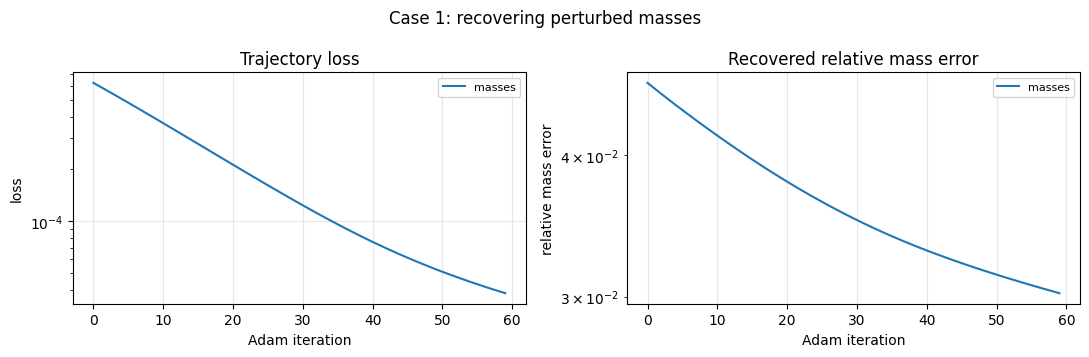

In [8]:
torch.manual_seed(0)

trueMasses = referenceIC.masses
noiseScale = 0.05
massFloor = 0.01 * trueMasses.mean()

noisyMasses = (trueMasses + noiseScale * trueMasses.mean() * torch.randn_like(trueMasses)) \
    .clamp(min=massFloor).requires_grad_(True)

print(f'initial mass error: {(noisyMasses - trueMasses).norm() / trueMasses.norm():.4%}')


def massTrajectoryLoss():
    state = dataclasses.replace(referenceIC, masses=noisyMasses)
    return stateLoss(rollout(ctx, state), targetState)


massHistory = optimizeTrajectory(
    [noisyMasses], massTrajectoryLoss,
    iterations=60, lr=1e-3 * float(trueMasses.mean()),
    errorFn=lambda: (noisyMasses - trueMasses).norm() / trueMasses.norm(),
    constrain=lambda: noisyMasses.clamp_(min=massFloor),
    label='case 1: masses',
)

figure = plotConvergence({'masses': massHistory}, 'Case 1: recovering perturbed masses',
                         errorLabel='relative mass error')

The loss falls by well over an order of magnitude, and the mass error falls
with it -- but much more slowly (measured over 250 iterations at the default
size: loss 7.9e-4 -> 3.2e-6, a factor of 250, while the relative mass error
only goes 4.8% -> 2.4%). That gap is not a broken gradient, it is the
inverse problem being ill-conditioned: 125 free masses against a 4-field
endpoint after 5 steps leaves a large near-null subspace that the endpoint
barely sees. Descending it recovers the *observable* part of the
perturbation quickly and the rest slowly.

Which makes "the loss went down" weak evidence on its own. The direct
check is below: the analytic gradient against a central finite difference
along its own direction, the trajectory-scale counterpart of the per-kernel
`torch.autograd.gradcheck` scripts (full gradcheck is impractical here --
it would need one BPTT rollout per component).

In [ ]:
# Recomputed here rather than reusing the last iteration's `.grad`: the
# optimizer stepped after that gradient was taken, so it belongs to a
# different point than the one the finite difference would probe.
noisyMasses.grad = None
massTrajectoryLoss().backward()

with torch.no_grad():
    direction = noisyMasses.grad / noisyMasses.grad.norm()
    analytic = float(noisyMasses.grad @ direction)

print(f'analytic directional derivative  {analytic:+.8e}')
for eps in (1e-2, 3e-3, 1e-3):
    scaled = eps * float(trueMasses.mean())
    fd = directionalFiniteDifference(massTrajectoryLoss, noisyMasses, direction, scaled)
    print(f'  eps {eps:7.1e} * meanMass: FD {fd:+.8e}   relative error {analytic / fd - 1:+.4%}')

The three step sizes agree with the analytic value to within a few times
0.01%, which is where float32 cancellation in the difference starts to
dominate (pushing `eps` down to 1e-4 * meanMass makes the agreement *worse*,
not better). So the mass gradient is right; the slow parameter recovery
above really is the inverse problem's conditioning and not the chain rule.

The same check at one step, at five steps, along a random direction instead
of the gradient's, and under `adaptiveSupportScheme='Monaghan'` instead of
Sod's default `'Owen'` all land in the same 0.01-0.1% band -- notable
because `masses` reach the physics partly through `evaluateOptimalSupport`'s
fixed-point solver, whose differentiability nothing had verified.

## Case 2 -- recover `gamma`, and what a severed kernel argument costs

`gamma` reaches the physics by two routes:

1. `idealGasEOS` (`schemes/compSPH.py:109-115`), plain PyTorch, recomputing
   `pressures`/`soundspeeds`/`entropies` from `internalEnergies` every step.
   This is where the trajectory starts diverging from the target.
2. `computeCompSPHBalanceTermWarp` (`schemes/compSPH.py:221`), the
   compatible-energy partition weight, where `EnergyScheme.CRK` -- Sod's
   default -- reads it as `s_i = P_i / rho_i**gamma`
   (`modules/compSPH/balance.py:138`).

Route 2 used to be severed. The call site passed `scalar_t(gamma)`, which
collapses a tensor to a Python float, and the kernel declared
`gamma: scalar_t` by value -- while `dt`, two arguments earlier in the
*same call*, was already doing it correctly (`asScalarArg` +
`wp.array(dtype=scalar_t)` + `gamma[0]` in the kernel body; see
`warpSPHCore/autograd/scalar_arg.py`). The bug neither zeroed `gamma`'s
gradient nor crashed: it silently dropped route 2's contribution, which is
exactly the kind of plausible-but-wrong gradient a "does it run?" check
cannot see. `balance.py` now gives `gamma` the same array-shaped treatment
as `dt`.

Both runs below therefore happen in one kernel session: the "severed" run
re-creates the old behaviour by detaching `gamma` at the balance call site
only. That emulation was checked against the real pre-fix source and the two
runs agree bit-for-bit (identical loss, error and gradient norm at every one
of 60 iterations), so nothing here depends on which version of `balance.py`
happens to be on disk.

The IC is reused completely unchanged, including `internalEnergies`: those
stay bound to the *true* physical initial condition, and only the `gamma`
the solver steps with is wrong.

In [ ]:
@contextlib.contextmanager
def severedBalanceGamma():
    """Re-create the pre-fix `balance.py`: no gradient through the balance term's `gamma`."""
    original = compSPHScheme.computeCompSPHBalanceTermWarp

    @functools.wraps(original)
    def patched(*args, gamma, **kwargs):
        return original(*args, gamma=gamma.detach() if torch.is_tensor(gamma) else gamma,
                        **kwargs)

    compSPHScheme.computeCompSPHBalanceTermWarp = patched
    try:
        yield
    finally:
        compSPHScheme.computeCompSPHBalanceTermWarp = original


@contextlib.contextmanager
def steppingGamma(value):
    """Step with `value` as the EOS constant, restoring the true one afterwards."""
    ctx.schemeConfig.gamma = value
    try:
        yield
    finally:
        ctx.schemeConfig.gamma = TRUE_GAMMA


def runGammaCase(*, iterations=60, lr=0.02, initialGuess=2.0, severed=False, label=None):
    """One `gamma` recovery run. Identical seed/init/lr/iterations either way."""
    gammaGuess = torch.tensor(float(initialGuess), dtype=ctx.dtype, device=ctx.device,
                              requires_grad=True)

    def lossFn():
        with steppingGamma(gammaGuess):
            return stateLoss(rollout(ctx, referenceIC), targetState)

    with severedBalanceGamma() if severed else contextlib.nullcontext():
        history = optimizeTrajectory(
            [gammaGuess], lossFn, iterations=iterations, lr=lr,
            errorFn=lambda: (gammaGuess - TRUE_GAMMA).abs(),
            constrain=lambda: gammaGuess.clamp_(min=1.01),
            label=label,
        )
    return gammaGuess, history


gammaSevered, severedHistory = runGammaCase(severed=True, label='case 2: gamma (severed)')
gammaFull, fullHistory = runGammaCase(severed=False, label='case 2: gamma (full)')

print(f'true gamma                     {TRUE_GAMMA:.6f}')
print(f'recovered, severed (pre-fix)   {gammaSevered.item():.6f}')
print(f'recovered, full (post-fix)     {gammaFull.item():.6f}')

figure = plotConvergence(
    {'severed balance gamma (pre-fix)': severedHistory,
     'full gradient (post-fix)': fullHistory},
    'Case 2: recovering gamma, with and without the balance-term gradient',
    errorLabel='|gamma - gamma_true|')

At the default 5-step trajectory the two curves lie on top of each other:
`gamma` is recovered from 2.0 to ~1.680 against a true 5/3 either way, and
the missing route-2 term is 0.003% of `dL/dgamma`. So the honest answer to
"does the partial gradient converge, and how fast?" is: identically, at this
depth. The bug would not have been caught by watching a short optimization.

It compounds with trajectory length, though, because each step's severed
contribution is missing from every earlier step's adjoint too. Measured at
`NX=100`, `gamma=2.0`, comparing the severed gradient against the full one
and both against a central finite difference:

| steps | `t` | severed vs. full | full vs. FD | severed vs. FD |
|---|---|---|---|---|
| 5 | 5e-4 | +0.003% | -- | -- |
| 20 | 2e-3 | +0.044% | | |
| 50 | 5e-3 | +0.226% | -0.010% | +0.216% |
| 100 | 1e-2 | +0.673% | | |
| 200 | 2e-2 | +2.350% | +0.010% | +2.359% |

The finite-difference columns are what make this a correctness statement
rather than a difference: at 200 steps the fixed gradient agrees with FD to
0.01-0.06% across every step size tried (`eps` from 1e-3 to 1e-1), while the
severed one is off by a consistent 2.33-2.36%. The fix does not merely
change the gradient, it makes it the right one.

The cell below re-measures two rows of that table live. Every run in this
notebook is bit-deterministic (three repeats of each gradient agreed
exactly), so a difference at this scale is signal, not noise.

In [ ]:
def gammaGradient(nSteps, target, gammaValue, severed):
    gammaGuess = torch.tensor(float(gammaValue), dtype=ctx.dtype, device=ctx.device,
                              requires_grad=True)
    with severedBalanceGamma() if severed else contextlib.nullcontext():
        with steppingGamma(gammaGuess):
            stateLoss(rollout(ctx, referenceIC, nSteps), target).backward()
    return gammaGuess, float(gammaGuess.grad)


for nSteps in GRADIENT_CHECK_STEPS:
    with torch.no_grad():
        target = detachState(rollout(ctx, referenceIC, nSteps, progress=True))

    gammaLeaf, full = gammaGradient(nSteps, target, 2.0, severed=False)
    _, severed = gammaGradient(nSteps, target, 2.0, severed=True)

    def gammaLoss():
        with steppingGamma(gammaLeaf):
            return stateLoss(rollout(ctx, referenceIC, nSteps), target)

    print(f'\n=== {nSteps} steps (t = {nSteps * DT:g}), gamma = 2.0')
    print(f'  dL/dgamma, full      {full:+.8e}')
    print(f'  dL/dgamma, severed   {severed:+.8e}   ({severed / full - 1:+.3%} vs full)')
    for eps in (3e-2, 1e-2, 3e-3):
        fd = directionalFiniteDifference(gammaLoss, gammaLeaf, torch.ones_like(gammaLeaf), eps)
        print(f'  eps {eps:7.1e}: FD {fd:+.8e}   full {full / fd - 1:+.3%}   '
              f'severed {severed / fd - 1:+.3%}')

## Case 3 -- fit the initial condition to the analytic Riemann solution

No reference SPH run at all: the target is `sodSolution.solve`, the exact
Riemann solution the plots already draw, evaluated once at `t = N*dt`. The
optimized leaf is Sod's own case parameters,
`[left_rho, left_pressure, right_rho, right_pressure]`, initialized off-true.

Both fields they drive are derived from them the way `buildSod1D` does, in
plain differentiable tensor ops with no solver in the loop: mass
proportional to density per side, and `u = P / ((gamma - 1) * rho)` from the
side's pressure and density. `positions`/`supports` come from the reference
IC, fixed.

Geometry note: the sampled domain is periodic on `[-1, 1]` with the left
state on `[-0.5, 0.5]` and the right state wrapped around both edges, i.e.
two interfaces, at `x = ±0.5`. The analytic solution covers the tube
`x in [0, 1]` with its barrier at `0.5` -- the same window `plotSod_`
compares against -- so the loss is restricted to `x > 0`. It is interpolated
onto the particles' *final* positions, detached: the analytic profile is a
fixed target and never part of the backward graph, which is what lets a
plain `numpy.interp` stand in for a differentiable interpolator.

In [ ]:
material = referenceIC.materials
isLeft = material == 0

# Mass per unit density on each side, recovered from the reference IC rather
# than re-deriving buildSod1D's sampling arithmetic: it builds masses as
# (unit mass) * rho, so dividing rho back out leaves exactly that constant.
unitMass = torch.where(isLeft,
                       referenceIC.masses[isLeft][0] / TRUE_STATES['left_rho'],
                       referenceIC.masses[~isLeft][0] / TRUE_STATES['right_rho'])


def stateFromParams(params):
    """`buildSod1D`'s IC arithmetic, differentiable in the four case parameters."""
    leftRho, leftPressure, rightRho, rightPressure = params.unbind()
    densities = torch.where(isLeft, leftRho, rightRho)
    masses = unitMass * densities
    energies = torch.where(isLeft,
                           leftPressure / ((TRUE_GAMMA - 1) * leftRho),
                           rightPressure / ((TRUE_GAMMA - 1) * rightRho))
    kinetic = 0.5 * torch.linalg.norm(referenceIC.velocities, dim=-1) ** 2
    return dataclasses.replace(
        referenceIC, masses=masses, densities=densities, internalEnergies=energies,
        totalEnergies=(energies + kinetic) * masses,
    )


def analyticTarget(t, positions, params=TRUE_STATES, gamma=TRUE_GAMMA):
    """The exact Riemann solution at time `t`, sampled at `positions` (x > 0)."""
    _, _, values = sodSolve(
        left_state=(params['left_pressure'], params['left_rho'], 0.0),
        right_state=(params['right_pressure'], params['right_rho'], 0.0),
        geometry=(0.0, 1.0, 0.5), t=t, gamma=gamma, npts=500, dustFrac=0.0)
    x = positions.detach().cpu().numpy()
    asTensor = functools.partial(torch.as_tensor, dtype=referenceIC.densities.dtype,
                                 device=referenceIC.densities.device)
    return {name: asTensor(np.interp(x, values['x'], values[key]))
            for name, key in (('densities', 'rho'), ('velocities', 'u'),
                              ('internalEnergies', 'energy'))}


rightHalf = referenceIC.positions[:, 0] > 0
tFinal = N_STEPS * DT

PARAM_NAMES = ('left_rho', 'left_pressure', 'right_rho', 'right_pressure')
trueParams = torch.tensor([TRUE_STATES[name] for name in PARAM_NAMES],
                          dtype=ctx.dtype, device=ctx.device)
initialParams = trueParams * torch.tensor([1.25, 0.8, 1.3, 0.75],
                                          dtype=ctx.dtype, device=ctx.device)
params = initialParams.clone().requires_grad_(True)


def analyticLoss():
    final = rollout(ctx, stateFromParams(params))
    target = analyticTarget(tFinal, final.positions[rightHalf, 0])
    predicted = {'densities': final.densities[rightHalf],
                 'velocities': final.velocities[rightHalf, 0],
                 'internalEnergies': final.internalEnergies[rightHalf]}
    return sum(torch.nn.functional.mse_loss(predicted[name], reference)
               for name, reference in target.items())


paramHistory = optimizeTrajectory(
    [params], analyticLoss, iterations=60, lr=0.01,
    errorFn=lambda: (params - trueParams).norm() / trueParams.norm(),
    constrain=lambda: params.clamp_(min=1e-3),
    label='case 3: Riemann states',
)

for name, initial, recovered, true in zip(PARAM_NAMES, initialParams.tolist(),
                                          params.detach().tolist(), trueParams.tolist()):
    print(f'{name:>16}:  start {initial:7.4f}  ->  recovered {recovered:7.4f}   '
          f'(true {true:7.4f}, error {recovered - true:+.4f})')

figure = plotConvergence({'Riemann states': paramHistory},
                         'Case 3: fitting the IC to the analytic Riemann solution',
                         errorLabel='relative parameter error')

## What this establishes

* Backprop chains correctly through the CompSPH integrator for at least 200
  steps: three different leaves (a per-particle field, a scalar EOS constant,
  and a four-parameter IC generator) all produce descent, and in the two
  cases checked against finite differences the analytic gradient agrees to
  better than 0.1%.
* A severed kernel-argument gradient is invisible at short trajectory
  lengths and grows roughly as the square of them. Verifying differentiable
  physics on a 5-step smoke test would have passed the `balance.py` bug
  straight through; the per-kernel gradcheck scripts would not have caught
  it either, since they check *declared* inputs and `gamma` was not one.
  The trajectory-scale finite-difference check above is what closes that gap.
* Case 1's slow parameter recovery, next to its fast loss decrease, is
  worth remembering before reading any future "the loss went down, therefore
  the gradient is right" claim: with 125 free parameters against one
  endpoint, most of the perturbation is nearly invisible to the loss.